# Model Selection Lab
In this lab, we will practice implementing and applying the model evaluation and selection techniques discussed in class. You will gain valuable skills in extracting the peak performance from any given model.

All  of  the  programming  assignments  are  to  be  done  in  Python  using  additional  libraries  specified  in  the  assignments.  There  are many  libraries  available,  some  of  which  we  will  be  using,  and  you  are  welcome  to  use  them  with  one  exception:  if  the  library  or  a  function  within  it  performs  the  specific  function  you  are  asked  to  code,  you  may  not  use  that  other  than  as  a  reference  to  compare  against. All  of  the  code  you  submit  must  be  your  own. Once you have completed an assignment, turn in your jupyter notebook with all the outputs shown.


### Preliminaries

Before you begin, make sure you have a properly operating Python environment with the Pandas, NumPy, Matplotlib, and Sci-kit Learn packages installed. If setup correctly, the following line of code should run without error:

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

Also make sure you have the following datasets downloaded from the assignment page and placed in a `datasets/` directory of your project folder. **Please do not change the folder structure to minimize issues when grading.**

In [28]:
wine_fn = "./datasets/wineQT.csv"
wine_fn_test = "./datasets/wineQT_test.csv"

## Part 1: Feature Selection

In this lab, we will be working with the Wine Quality dataset. This data contains samples of various wines and their respective chemical properties. The quality of the wine is ranked on a scale from 3-8. The goal of your machine learning model will be to predict the quality of the wine given these chemical properties.

Compared to previous labs and in-class examples, the Wine dataset is the most complex data we have seen so far. The dataset is imbalanced (there are a lot more examples of 5 and 6 quality than other levels) and the connection between properties and quality is unintuitive and cannot be easily visualized. These points are illustrated below.

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')


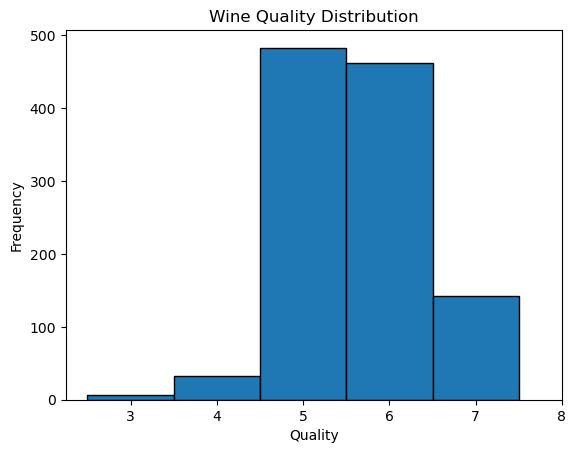

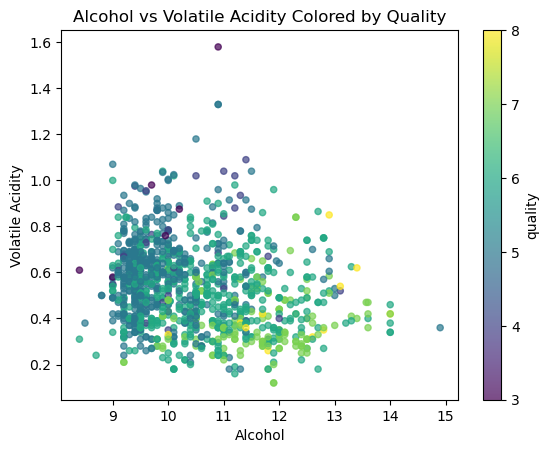

In [29]:
df = pd.read_csv(wine_fn)
df_test = pd.read_csv(wine_fn_test)

print(df.columns)

# Visualize Wine Quality Distribution
plt.hist(df['quality'], bins=np.arange(df['quality'].min(), df['quality'].max()+1)-0.5, edgecolor='black')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.xticks(np.arange(df['quality'].min(), df['quality'].max()+1))
plt.show()

# Visualize a two parameters on a scatter plot colored with quality
df.plot.scatter(x='alcohol', y='volatile acidity', c='quality', colormap='viridis', alpha=0.7)
plt.title('Alcohol vs Volatile Acidity Colored by Quality')
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.show()

The dataset for this lab also has a separate testing dataset that we will compare against, rather than relying on a random split.

Given the difficulty in classifying this dataset, it will be vital to find meaningful features for training. As a baseline, I have setup a simple polynomial SVM for classifying on every available feature in the dataset.



In [30]:
# Build training and testing datasets
X_train = df.drop(columns=['quality'])
y_train = df['quality']

X_test = df_test.drop(columns=['quality'])
y_test = df_test['quality']

# Train SVM classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='poly')
model.fit(X_train, y_train)
predictions = model.predict(X_train)
accuracy = accuracy_score(y_train, predictions)
print(f"Training Accuracy: {accuracy:.3f}")
predictions_test = model.predict(X_test)
accuracy_test = accuracy_score(y_test, predictions_test)
print(f"Testing Accuracy: {accuracy_test:.3f}")

Training Accuracy: 0.447
Testing Accuracy: 0.486


Training on every feature is not the optimal setup. Your goal is to find a better set of features to train on.

For this part of the lab, please do the following:

- Plot a correlation matrix and/or pair plots of the available features.
- Use intuition and the information gained from the plots to manually select up to 5 features to train on. Train that model and print out the training and testing accuracy. Use the same polynomial SVM model.
- Use an automatic feature selector (such as SelectKBest) to automatically select up to 3 features to train on. Train that model and print out the training and testing accuracy. Use the same polynomial SVM model.

Compare both your models to the training and testing accuracy above. In both cases, you should be able to get an accuracy above 50\%.

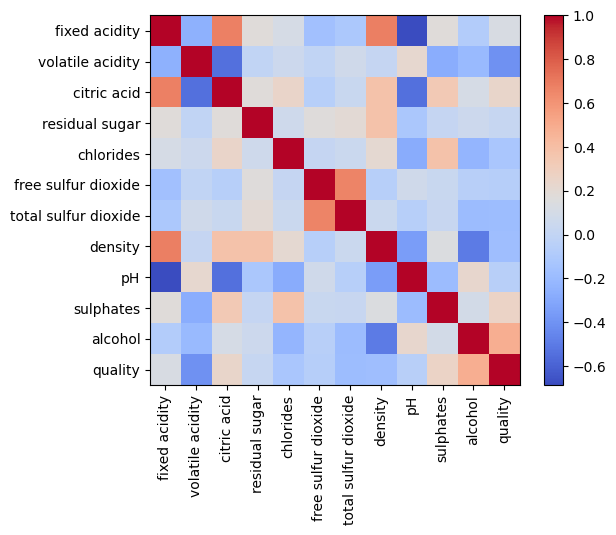

Training Accuracy: 0.565
Testing Accuracy: 0.582

Selected features: Index(['volatile acidity', 'sulphates', 'alcohol'], dtype='object')
Training Accuracy: 0.570
Testing Accuracy: 0.586


In [31]:
# correlation matrix
X = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality']]
y = df['quality']
corr_matrix = X.corr()
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.show()

# pair plot
import seaborn as sns
#sns.pairplot(X)
#plt.show()

# select five features
from sklearn.model_selection import train_test_split
selected_features = ['volatile acidity', 'citric acid', 'sulphates', 'density', 'alcohol']
# X_train, X_test, y_train, y_test = train_test_split(selected_features, y, test_size=0.2, random_state=42)
X_train = df[selected_features]
y_train = df['quality']
X_test = df_test[selected_features]
y_test = df_test['quality']

model = SVC(kernel='poly')
model.fit(X_train, y_train)
predictions = model.predict(X_train)
accuracy = accuracy_score(y_train, predictions)
print(f"Training Accuracy: {accuracy:.3f}")
predictions_test = model.predict(X_test)
accuracy_test = accuracy_score(y_test, predictions_test)
print(f"Testing Accuracy: {accuracy_test:.3f}")

# automatically select features
from sklearn.feature_selection import SelectKBest, f_classif
X_train = df.drop(columns=['quality'])
X_test = df_test.drop(columns=['quality'])
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)
print("\nSelected features:", X_train.columns[selector.get_support()])

model = SVC(kernel='poly')
model.fit(X_train_selected, y_train)
predictions = model.predict(X_train_selected)
accuracy = accuracy_score(y_train, predictions)
print(f"Training Accuracy: {accuracy:.3f}")
predictions_test = model.predict(X_test_selected)
accuracy_test = accuracy_score(y_test, predictions_test)
print(f"Testing Accuracy: {accuracy_test:.3f}")

#model.fit(X_train, y_train)
#y_pred = model.predict(X_test)

#accuracy = accuracy_score(y_test, y_pred)
#print("Model accuracy with automatically selected features:", accuracy)

#### Answer the following questions in the markdown cell below: 

#### How did you decide which features you would use in your manually selected model? What appeared to be the most effective in increasing the accuracy? How did the accuracy change between manually selected and automatically selected features? Was this more or less than you were expecting?

For manually selected features, I chose them based on the correlation matrix and how well each feature correlated with each other. To increase accuracy, selecting features that correlate most with quality appeared to be most effective. Accuracy increased with automatically selected features, but not as much as I would have expected.

## Part 2: Implementing Best Practices for Model Selection

Now that you have found the best features to train on, we want to improve our model even further by implementing some of the best practices that have been discussed in class.

For this part of the lab, implement the following components on the model:

- Scaling of the data using StandardScaler or MinMaxScaler
- Parameter Tuning of the SVM using GridSearchCV or RandomizedSearchCV
- Cross Fold Validation using KFold or StratifiedKFold (can be incorporated as part of the parameter tuning)

For the SVM, you can tune parameters such as kernel, C, and scale. **Note: Do not use a linear kernel as it will not converge and stall your Jupyter Notebook.**

Experiment with these various configuration settings until you find as high a testing accuracy as possible. As a note, Dr. Hart was able to acheive an accuracy above 60\%.


In [32]:
# scaling data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='poly')
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)
print(f"Testing Accuracy (with Standard scaling): {accuracy:.3f}")

#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

#model = SVC(kernel='poly')
#model.fit(X_train_scaled, y_train)
#predictions = model.predict(X_test_scaled)
#accuracy = accuracy_score(y_test, predictions)
#print(f"Testing Accuracy (with MinMax scaling): {accuracy:.3f}")

# parameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [.1,.5,1,3,5,10],
    'degree': [2,3],
    'gamma': ['scale', 'auto'],
    'kernel': ['poly']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best parameters (GridSearchCV):", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)
print("Test set accuracy:", grid.score(X_test_scaled, y_test))

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'C': uniform(0.1, 10),
    'degree': randint(2, 5),
    'gamma': ['scale', 'auto'],
    'kernel': ['poly']
}

random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search.fit(X_train_scaled, y_train)

print("Best parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)
print("Test set accuracy:", random_search.score(X_test_scaled, y_test))

Testing Accuracy (with Standard scaling): 0.717
Best parameters (GridSearchCV): {'C': 3, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validation score: 0.5634222017926913
Test set accuracy: 0.7627772420443587
Best parameters (RandomizedSearchCV): {'C': np.float64(3.1424224295953773), 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validation score: 0.5616601547536966
Test set accuracy: 0.7647058823529411


#### Answer the following questions in the markdown cell below: 

#### What did you use as your final configuration settings. What steps taken appeared to be the most effective in increasing the accuracy?

I used the StandardScaler from sklearn as it had a higher accuracy score than the MinMaxScaler. My results show both GridSearchCV and RandomizedSearchCV; GridSearchCV gives a slightly higher accuracy score of 56.34% with a C value of 3, degree of 3, scale, and polynomial SVM. Trying a variety of C values ranging from 0.1 to 10 and degrees ranging from 2 to 5 seemed to be the most effective in increasing accuracy.

## Part 3: Evaluation Metrics

For this next part of the lab, we want to dive deeper into the evaluation metrics we discussed in class.

For this wine quality scenario, a 3 or 4 quality score is considered a bad wine and 5+ is considered a good wine. Let's binarize the quality data to make our quality mark good and bad wine. We'll also use the features alcohol, citric acid, and density as our inputs.

In [33]:
# Create logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import Binarizer

X_train_lg = X_train[['alcohol', 'citric acid', 'density']]
X_test_lg = X_test[['alcohol', 'citric acid', 'density']]

# Binarize the target variable for logistic regression (e.g., quality >= 5 as good)
y_train_lg = Binarizer(threshold=4.5).fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_lg = Binarizer(threshold=4.5).fit_transform(y_test.values.reshape(-1, 1)).ravel()

print("Number of good wines in training set:", np.sum(y_train_lg))
print("Number of good wines in test set:", np.sum(y_test_lg))
print("Number of bad wines in training set:", np.sum(1 - y_train_lg))
print("Number of bad wines in test set:", np.sum(1 - y_test_lg))

Number of good wines in training set: 1104
Number of good wines in test set: 1003
Number of bad wines in training set: 39
Number of bad wines in test set: 34


This binarization is helpful for making our model more meaningful for decision making. A producer of wines does not want to sell a bottle of wine if it is considered poor. However, this has made our dataset incredibly imbalanced. If we naively train a model like logistic regression and use its default threshold, it will appear to be doing well with high accuracy...

In [34]:
model = LogisticRegression(max_iter=200)
model.fit(X_train_lg, y_train_lg)
predictions_logreg = model.predict(X_train_lg)
accuracy_logreg = accuracy_score(y_train_lg, predictions_logreg)
print(f"Training Accuracy (Logistic Regression): {accuracy_logreg:.3f}")
predictions_test_logreg = model.predict(X_test_lg)
accuracy_test_logreg = accuracy_score(y_test_lg, predictions_test_logreg)
print(f"Testing Accuracy (Logistic Regression): {accuracy_test_logreg:.3f}")

Training Accuracy (Logistic Regression): 0.966
Testing Accuracy (Logistic Regression): 0.967


... but in reality it is simply predicting that every wine is good.

In [35]:
# Determine the number of bad wines listed as good (false positives)
false_positives = np.sum((predictions_test_logreg == 1) & (y_test_lg == 0))
print(f"Number of bad wines listed as good (false positives): {false_positives}")
print(f"Total number of bad wines in test set: {np.sum(1 - y_test_lg)}")

Number of bad wines listed as good (false positives): 34
Total number of bad wines in test set: 34


We need to adjust the threshold of this predictor to better match the need in a real use case. We want to minimize the likelihood that a bad wine gets listed as good while keeping as a high an accuracy as possible.

For this part of the lab, please do the following:

- For the training set, use the model to predict the probabilities of the training data with `model.predict_proba`.
- Use `sklearn.metrics.roc_curve` and `sklearn.metrics.auc` to retreive the false positive rates and true positive rates at each threshold, and compute the auc score.
- Plot the ROC curve for these predictions.
- Iterate through the thresholds list to find the lowest possible false positive rate while maintaining an **F1-score above 70%**
- For the testing set, use the model to predict the probabilities and apply this threshold. Print out the test set false postive rate and F1 score.

AUC Score: 0.652


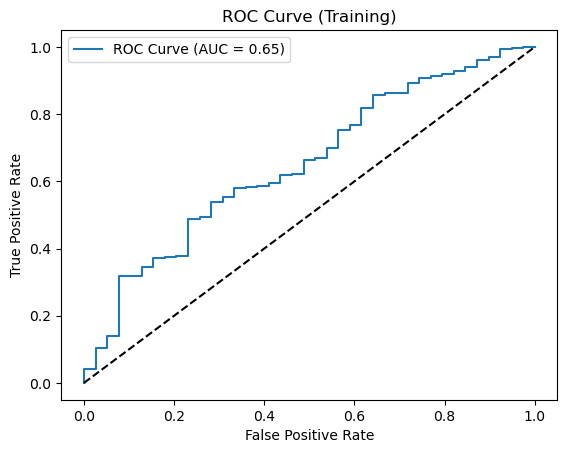

Best Threshold with F1 > 0.70: 0.964
Lowest False Positive Rate: 0.308
Test False Positive Rate: 0.324
Test F1 Score: 0.714


In [36]:
# predict probabilities
y_train_prob = model.predict_proba(X_train_lg)[:, 1]

# ROC curve, AUC
from sklearn.metrics import roc_curve, auc, f1_score

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train_lg, y_train_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
print(f"AUC Score: {roc_auc:.3f}")

# plot ROC curve
import matplotlib.pyplot as plt
plt.figure()
plt.plot(false_positive_rate, true_positive_rate, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Training)')
plt.legend()
plt.show()

# find lowest possible false_positive_rate with F1 > 0.70
best_threshold = 0.5
best_false_positive_rate = 1.0
for threshold in thresholds:
    preds = (y_train_prob >= threshold).astype(int)
    f1 = f1_score(y_train_lg, preds)
    fp = ((preds == 1) & (y_train_lg == 0)).sum()
    tn = ((preds == 0) & (y_train_lg == 0)).sum()
    false_positive_rate_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    if f1 >= 0.7 and false_positive_rate_val < best_false_positive_rate:
        best_false_positive_rate = false_positive_rate_val
        best_threshold = threshold
print(f"Best Threshold with F1 > 0.70: {best_threshold:.3f}")
print(f"Lowest False Positive Rate: {best_false_positive_rate:.3f}")

# predict probabilities using threshold on test set
y_test_prob = model.predict_proba(X_test_lg)[:, 1]
test_preds = (y_test_prob >= best_threshold).astype(int)

test_f1 = f1_score(y_test_lg, test_preds)
false_positive = ((test_preds == 1) & (y_test_lg == 0)).sum()
true_negative = ((test_preds == 0) & (y_test_lg == 0)).sum()
test_false_positive_rate = false_positive / (false_positive + true_negative) if (false_positive + true_negative) > 0 else 0
print(f"Test False Positive Rate: {test_false_positive_rate:.3f}")
print(f"Test F1 Score: {test_f1:.3f}")

#### Answer the following questions in the markdown cell below: 

#### Forcing a small false positive rate does decrease the F1 score drastically. What would this trade-off indicate from a business standpoint? What additional measures could be taken to improve the current models accuracy without affecting the false postive rate?

The trade-off between false positive rate and F1 score could indicate that we only sell good wine and avoid selling bad wine and possibly some good wine. More data can usually help improve a models' accuracy without affecting the false positive rate.